In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
import entropy_utils as entu


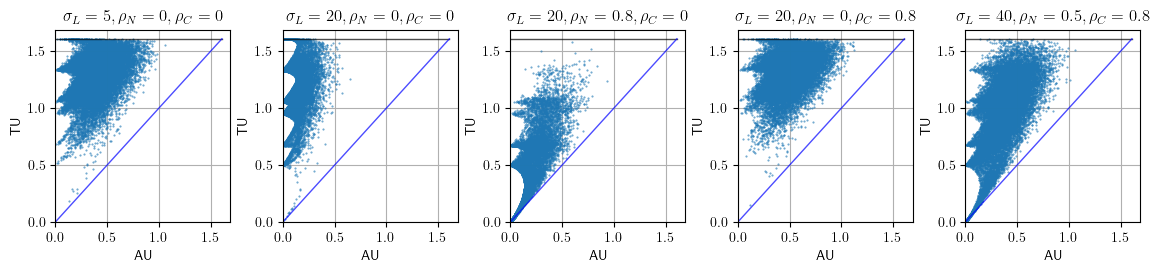

In [39]:
params = [(5, 0, 0), (20, 0, 0), (20, 0.8, 0), (20, 0, 0.8), (40, 0.5, 0.8)]
C = 5
N = 5
plot_TU = True
plot_xy = False
simplify_labels = False
plot_curves = False
alpha = 0.7
lw = 1
fig, axs = plt.subplots(1, len(params), figsize=(2.8*len(params), 2.5))
if len(params) == 1:
    axs = [axs]
for i,(logit_std, network_corr, class_corr) in enumerate(params):

    probs = entu.simulate_probs(num_classes = C,
                    num_samples = 20000,
                    num_ensemble = N,
                    logit_std = logit_std,
                    network_corr = network_corr,
                    class_corr = class_corr)

    aleatoric, epistemic, total = entu.uncertainties(probs)
    max_tu = np.log(C)
    max_eu = np.log(min(N,C))
    #plt.xscale('log')
    #plt.yscale('log')

    AUs,EUs,TUs, Cws = entu.theoretical_boundaries_all(num_classes=C, num_ensemble=N,
                                                    include_eq_pairs=True,
                                                    detailed=True)
    if plot_TU:
        axs[i].plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,max_tu], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,max_tu], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("TU")
    else:
        axs[i].plot(aleatoric.numpy(), epistemic.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("EU")
    if plot_curves:
        for AU,EU,TU,cw in zip(AUs,EUs,TUs, Cws):
            label = ",".join([(f"{item}" if p==0 else f"\\underline{{{item}}}") for item, p in zip(cw[0], cw[1])])
            if simplify_labels:
                for i in range(C):
                    if label.endswith(",0"):
                        label = label[:-2]
                label = f"[{label}, ...]"
            else:
                label = f"[{label}]"
            axs[i].plot(AU, TU if plot_TU else EU, "-", linewidth=2, label=label)
    plt.rcParams["text.usetex"] = True
    axs[i].set_xlim(-0.0*max_tu, 1.05*max_tu)
    axs[i].set_ylim(-0.0*max_tu, 1.05*max_tu)
    if plot_xy:
        x_min,x_max = axs[i].get_xlim()
        y_min,y_max = axs[i].get_ylim()
        axs[i].plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
        axs[i].set_xlim(x_min,x_max)
        axs[i].set_ylim(y_min,y_max)
    axs[i].set_title(f"$\\sigma_{{L}}={logit_std}, \\rho_N={network_corr}, \\rho_C={class_corr}$")
    axs[i].grid()
#use tex
plt.rcParams["text.usetex"] = True
fig.subplots_adjust(
    wspace=0.3,  # horizontal space between subplots
    hspace=0.0,  # vertical space between subplots
)
plt.savefig(f"../writing/images/triangles0.png", dpi=300, bbox_inches='tight')

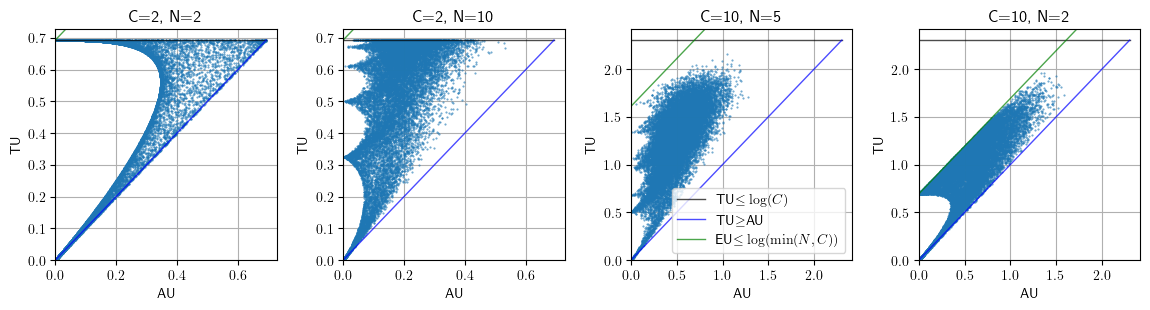

In [82]:
pairs = [(2,2), (2,10), (10,5), (10,2)]
#pairs = [(10,2)]
plot_TU = True
plot_xy = False
simplify_labels = False
plot_curves = False
alpha = 0.7
lw = 1
fig, axs = plt.subplots(1, len(pairs), figsize=(3.5*len(pairs), 3))
if len(pairs) == 1:
    axs = [axs]
for i,(C,N) in enumerate(pairs):

    probs = entu.simulate_probs(num_classes = C,
                    num_samples = 20000,
                    num_ensemble = N,
                    logit_std = 40,
                    network_corr = 0.5,
                    class_corr = 0.8)

    aleatoric, epistemic, total = entu.uncertainties(probs)
    max_tu = np.log(C)
    max_eu = np.log(min(N,C))
    #plt.xscale('log')
    #plt.yscale('log')

    AUs,EUs,TUs, Cws = entu.theoretical_boundaries_all(num_classes=C, num_ensemble=N,
                                                    include_eq_pairs=True,
                                                    detailed=True)
    if plot_TU:
        axs[i].plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,max_tu], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,max_tu], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_eu,max_tu+max_eu], 'g', label=r"EU$\leq\log(\min(N,C))$", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("TU")
    else:
        axs[i].plot(aleatoric.numpy(), epistemic.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        axs[i].plot([0,0],[max_eu,max_eu], 'g', label=r"EU$\leq\log(\min(N,C))$", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("EU")
    if plot_curves:
        for AU,EU,TU,cw in zip(AUs,EUs,TUs, Cws):
            label = ",".join([(f"{item}" if p==0 else f"\\underline{{{item}}}") for item, p in zip(cw[0], cw[1])])
            if simplify_labels:
                for i in range(C):
                    if label.endswith(",0"):
                        label = label[:-2]
                label = f"[{label}, ...]"
            else:
                label = f"[{label}]"
            axs[i].plot(AU, TU if plot_TU else EU, "-", linewidth=2, label=label)
    plt.rcParams["text.usetex"] = True
    axs[i].set_xlim(-0.0*max_tu, 1.05*max_tu)
    axs[i].set_ylim(-0.0*max_tu, 1.05*max_tu)
    if plot_xy:
        x_min,x_max = axs[i].get_xlim()
        y_min,y_max = axs[i].get_ylim()
        axs[i].plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
        axs[i].set_xlim(x_min,x_max)
        axs[i].set_ylim(y_min,y_max)
    if i==len(pairs)-2:
        axs[i].legend(ncol=1)
    axs[i].set_title(f"C={C}, N={N}", fontsize=12)
    axs[i].grid()
fig.subplots_adjust(
    wspace=0.3,  # horizontal space between subplots
    hspace=0.0,  # vertical space between subplots
)
plt.savefig(f"../writing/images/triangles1.png", dpi=300, bbox_inches='tight')

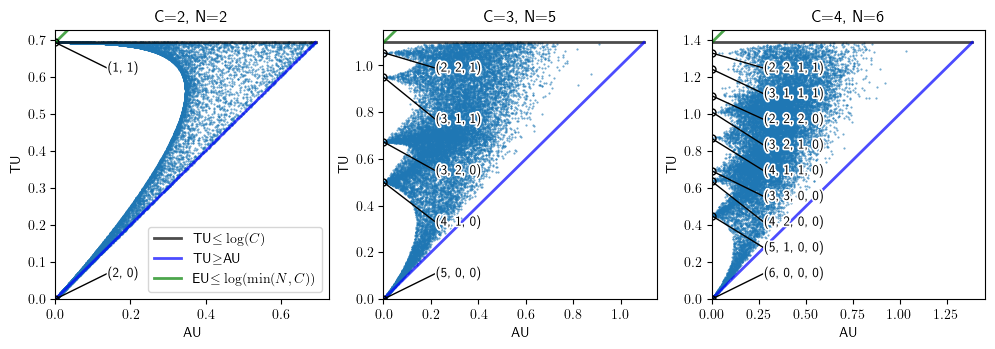

In [9]:
import matplotlib.patheffects as pe

pairs = [(2,2), (3,5), (4,6)]
plot_TU = True
plot_xy = False
simplify_labels = False
plot_curves = False
plot_points = True
alpha = 0.7
lw = 2
fig, axs = plt.subplots(1, len(pairs), figsize=(4*len(pairs), 3.5))
if len(pairs) == 1:
    axs = [axs]
for i,(C,N) in enumerate(pairs):

    probs = entu.simulate_probs(num_classes = C,
                    num_samples = 20000,
                    num_ensemble = N,
                    logit_std = 40,
                    network_corr = 0.5,
                    class_corr = 0.8)

    aleatoric, epistemic, total = entu.uncertainties(probs)
    max_tu = np.log(C)
    max_eu = np.log(min(N,C))
    #plt.xscale('log')
    #plt.yscale('log')

    AUs,EUs,TUs, Cws = entu.theoretical_boundaries_all(num_classes=C, num_ensemble=N,
                                                    include_eq_pairs=True,
                                                    detailed=True)
    if plot_TU:
        axs[i].plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,max_tu], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,max_tu], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_eu,max_tu+max_eu], 'g', label=r"EU$\leq\log(\min(N,C))$", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("TU")
    else:
        axs[i].plot(aleatoric.numpy(), epistemic.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        axs[i].plot([0,0],[max_eu,max_eu], 'g', label=r"EU$\leq\log(\min(N,C))$", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("EU")
    if plot_curves:
        for AU,EU,TU,cw in zip(AUs,EUs,TUs, Cws):
            label = ",".join([(f"{item}" if p==0 else f"\\underline{{{item}}}") for item, p in zip(cw[0], cw[1])])
            if simplify_labels:
                for i in range(C):
                    if label.endswith(",0"):
                        label = label[:-2]
                label = f"[{label}, ...]"
            else:
                label = f"[{label}]"
            axs[i].plot(AU, TU if plot_TU else EU, "-", linewidth=2, label=label)
    if plot_points:
        comps = list(entu.unique_compositions(N, C))
        TUs = [entu.entropy(np.array(comp)/N) for comp in comps]
        AUs = [0 for comp in comps]
        EUs = [TU_i - AU_i for TU_i, AU_i in zip(TUs, AUs)]
        # sort comps by TU vals
        sorted_indices = np.argsort(TUs)
        comps = [comps[i] for i in sorted_indices]
        TUs = [TUs[i] for i in sorted_indices]
        AUs = [AUs[i] for i in sorted_indices]
        EUs = [EUs[i] for i in sorted_indices]
        text_x = 0.2 * max_tu
        text_ys = np.linspace(0.1 * max_tu, 0.9 * max_tu, len(comps))

        for AU_i, EU_i, TU_i, comp, text_y in zip(
            AUs, EUs, TUs, comps, text_ys
        ):
            point_y = TU_i if plot_TU else EU_i

            axs[i].plot(
                AU_i, point_y, 'ok', markersize=5,
                markerfacecolor='none', alpha=1.0, linewidth=2
            )
            axs[i].plot(
                [AU_i, text_x], [point_y, text_y],
                'k-', linewidth=1
            )
            axs[i].text(
                text_x, text_y, f"{comp}",
                fontsize=10, ha="left", va="center",
                path_effects=[
                    pe.withStroke(linewidth=2.5, foreground="white")
                ]
            )
    plt.rcParams["text.usetex"] = True
    axs[i].set_xlim(-0.0*max_tu, 1.05*max_tu)
    axs[i].set_ylim(-0.0*max_tu, 1.05*max_tu)
    if plot_xy:
        x_min,x_max = axs[i].get_xlim()
        y_min,y_max = axs[i].get_ylim()
        axs[i].plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
        axs[i].set_xlim(x_min,x_max)
        axs[i].set_ylim(y_min,y_max)
    if i==0:
        axs[i].legend(ncol=1)
    axs[i].set_title(f"C={C}, N={N}", fontsize=12)
    #axs[i].grid()
fig.subplots_adjust(
    wspace=0.2,  # horizontal space between subplots
    hspace=0.0,  # vertical space between subplots
)
plt.savefig(f"../writing/images/triangles2.png", dpi=300, bbox_inches='tight')

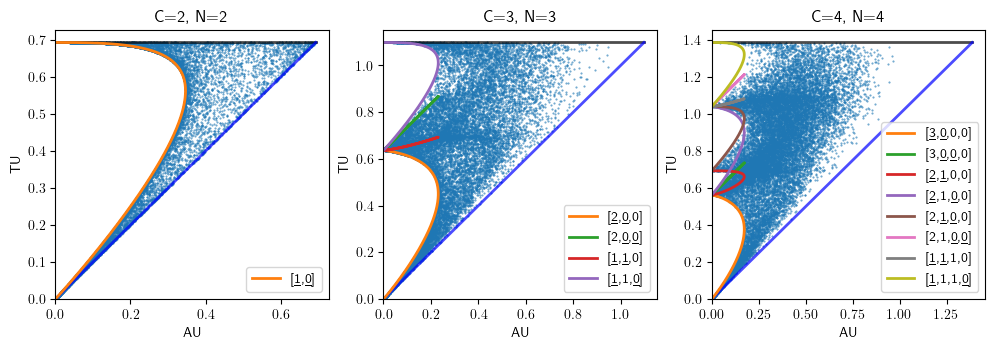

In [17]:
import matplotlib.patheffects as pe

pairs = [(2,2), (3,3), (4,4)]
plot_TU = True
plot_xy = False
simplify_labels = False
plot_curves = True
alpha = 0.7
lw = 2
fig, axs = plt.subplots(1, len(pairs), figsize=(4*len(pairs), 3.5))
if len(pairs) == 1:
    axs = [axs]
for i,(C,N) in enumerate(pairs):

    probs = entu.simulate_probs(num_classes = C,
                    num_samples = 20000,
                    num_ensemble = N,
                    logit_std = 40,
                    network_corr = 0.5,
                    class_corr = 0.8)

    aleatoric, epistemic, total = entu.uncertainties(probs)
    max_tu = np.log(C)
    max_eu = np.log(min(N,C))
    #plt.xscale('log')
    #plt.yscale('log')

    AUs,EUs,TUs, Cws = entu.theoretical_boundaries_all(num_classes=C, num_ensemble=N,
                                                    include_eq_pairs=True,
                                                    detailed=False)
    if plot_TU:
        axs[i].plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,max_tu], 'k-', alpha=alpha, linewidth=lw)#, label=r"TU$\leq\log(C)$")
        axs[i].plot([0,max_tu],[0,max_tu], 'b', alpha=alpha, linewidth=lw)#, label=r"TU$\geq$AU")
        #axs[i].plot([0,max_tu],[max_eu,max_tu+max_eu], 'g', label=r"EU$\leq\log(\min(N,C))$", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("TU")
    else:
        axs[i].plot(aleatoric.numpy(), epistemic.numpy(), '.',  markersize=1, alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        axs[i].plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        #axs[i].plot([0,0],[max_eu,max_eu], 'g', label=r"EU$\leq\log(\min(N,C))$", alpha=alpha, linewidth=lw)
        axs[i].set_xlabel("AU")
        axs[i].set_ylabel("EU")
    if plot_curves:
        for AU,EU,TU,cw in zip(AUs,EUs,TUs, Cws):
            label = ",".join([(f"{item}" if p==0 else f"\\underline{{{item}}}") for item, p in zip(cw[0], cw[1])])
            if simplify_labels:
                for i in range(C):
                    if label.endswith(",0"):
                        label = label[:-2]
                label = f"[{label}, ...]"
            else:
                label = f"[{label}]"
            axs[i].plot(AU, TU if plot_TU else EU, "-", linewidth=2, label=label)
    plt.rcParams["text.usetex"] = True
    axs[i].set_xlim(-0.0*max_tu, 1.05*max_tu)
    axs[i].set_ylim(-0.0*max_tu, 1.05*max_tu)
    if plot_xy:
        x_min,x_max = axs[i].get_xlim()
        y_min,y_max = axs[i].get_ylim()
        axs[i].plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
        axs[i].set_xlim(x_min,x_max)
        axs[i].set_ylim(y_min,y_max)
    axs[i].legend(ncol=1)
    axs[i].set_title(f"C={C}, N={N}", fontsize=12)
    #axs[i].grid()
fig.subplots_adjust(
    wspace=0.2,  # horizontal space between subplots
    hspace=0.0,  # vertical space between subplots
)
plt.savefig(f"../writing/images/triangles3.png", dpi=300, bbox_inches='tight')

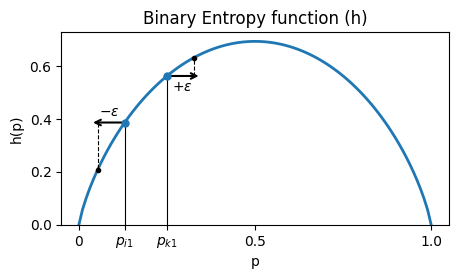

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def binary_entropy(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

t = np.linspace(0, 1, 100)

plt.figure(figsize=(5, 2.5))
plt.plot(t, binary_entropy(t), linewidth=2)

# Original points
p1, p2 = 0.13, 0.25
h1, h2 = binary_entropy(p1), binary_entropy(p2)

# Solid vertical lines from h(p) down to the x-axis
plt.plot(
    [p1, p1],
    [0, h1],
    color='black',
    linewidth=0.8
)

plt.plot(
    [p2, p2],
    [0, h2],
    color='black',
    linewidth=0.8
)

# Custom x-ticks
plt.xticks(
    [0, p1, p2, 0.5, 1.0],
    [
        '0',
        r'$p_{i1}$',
        r'$p_{k1}$',
        '0.5',
        '1.0'
    ]
)

# Keep original points blue and slightly larger
plt.plot([p1, p2], [h1, h2], 'o', color="C0", markersize=5, zorder=4)

# Epsilon displacement
eps = 0.09

p1_eps = p1 - eps
p2_eps = p2 + eps

h1_eps = binary_entropy(p1_eps)
h2_eps = binary_entropy(p2_eps)

# Put dashed line slightly before the visible arrowhead
dash_frac = 0.85
p1_dash = p1 - dash_frac * eps
p2_dash = p2 + dash_frac * eps

# Horizontal arrows
plt.annotate(
    '',
    xy=(p1_eps, h1),
    xytext=(p1, h1),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        color='black',
        shrinkA=0,
        shrinkB=0
    )
)

plt.annotate(
    '',
    xy=(p2_eps, h2),
    xytext=(p2, h2),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        color='black',
        shrinkA=0,
        shrinkB=0
    )
)

# Labels above arrows
plt.text(
    (p1 + p1_eps) / 2,
    h1 + 0.025,
    r'$-\epsilon$',
    ha='center'
)

plt.text(
    (p2 + p2_eps) / 2,
    h2 - 0.055,
    r'$+\epsilon$',
    ha='center'
)

# Black dashed vertical lines
plt.plot(
    [p1_dash, p1_dash],
    [h1, binary_entropy(p1_dash)],
    '--',
    color='black',
    linewidth=0.8
)

plt.plot(
    [p2_dash, p2_dash],
    [h2, binary_entropy(p2_dash)],
    '--',
    color='black',
    linewidth=0.8
)

# Black points at the perturbed entropy values
plt.plot(
    p1_dash,
    binary_entropy(p1_dash),
    'ko',
    markersize=3,
    zorder=5
)

plt.plot(
    p2_dash,
    binary_entropy(p2_dash),
    'ko',
    markersize=3,
    zorder=5
)

plt.xlabel('p')
plt.ylabel('h(p)')
plt.title('Binary Entropy function (h)')
#plt.grid()
plt.ylim(0, None)


plt.savefig(f"../writing/images/binary_entropy_shift.pdf", dpi=300, bbox_inches='tight')

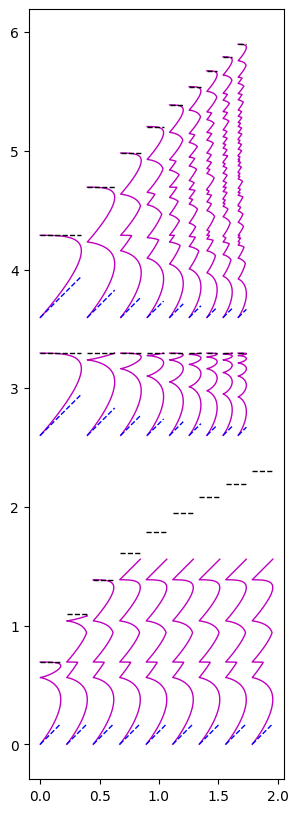

In [41]:
import matplotlib.patheffects as pe

pairs = [[(i,i) for i in range(2, 11)],
         [(2,i) for i in range(2, 11)],
         [(i,4) for i in range(2, 11)]]
pairs = pairs[::-1]
lw = 1
color = "m"
eps_x = 0.05
eps_y = 0.3
fig = plt.figure(figsize=(8, 10))
delta_y = 0
for j, pairs_j in enumerate(pairs):
    delta_x = 0
    max_TU_all = 0
    for i,(C,N) in enumerate(pairs_j):

        AU,EU,TU = entu.get_theoretical_min_boundary(num_classes=C, num_ensemble=N,
                                                        interp=False,
                                                        detailed=False)
        max_AU = np.log(2)/N
        max_TU = np.log(C)

        plt.plot(AU+delta_x, TU+delta_y, lw=lw, color=color)

        plt.plot([delta_x, delta_x+max_AU], [delta_y+max_TU, delta_y+max_TU], "k--", lw=lw)
        plt.plot([delta_x, delta_x+max_AU], [delta_y, delta_y+max_AU], "b--", lw=lw)
        delta_x += max_AU + eps_x
        max_TU_all = max(max_TU_all, max_TU)
    delta_y += max_TU_all + eps_y
plt.gca().set_aspect('equal', adjustable='box')

#plt.savefig(f"../writing/images/boundary_shapes.png", dpi=300, bbox_inches='tight')

(0.0, 2.417714347643748)

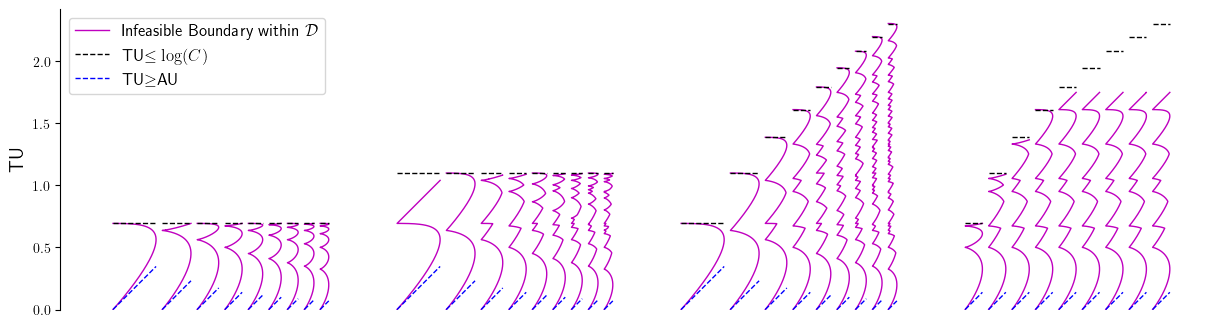

In [56]:
import matplotlib.patheffects as pe

pairs = [[(2,i) for i in range(2, 11)],
         [(3,i) for i in range(2, 11)],
         [(i,i) for i in range(2, 11)],
         [(i,5) for i in range(2, 11)]]
lw = 1
color = "m"
eps_x = 0.05
eps_y = 0.5
fig = plt.figure(figsize=(15, 10))
delta_x = 0
first = True
for j, pairs_j in enumerate(pairs):
    for i,(C,N) in enumerate(pairs_j):

        AU,EU,TU = entu.get_theoretical_min_boundary(num_classes=C, num_ensemble=N,
                                                        interp=False,
                                                        detailed=False)
        max_AU = np.log(2)/N
        max_TU = np.log(C)

        plt.plot(AU+delta_x, TU, lw=lw, color=color, 
                 label=r"Infeasible Boundary within $\mathcal{D}$" if first else None)

        plt.plot([delta_x, delta_x+max_AU], [max_TU, max_TU], "k--", lw=lw,
                    label=r"TU$\leq\log(C)$" if first else None)
        plt.plot([delta_x, delta_x+max_AU], [0, max_AU], "b--", lw=lw,
                    label=r"TU$\geq$AU" if first else None)
        first = False
        delta_x += max_AU + eps_x
    delta_x += eps_y
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc="upper left", fontsize=12)
# latex formatting
plt.rcParams["text.usetex"] = True
#turn off everything but the y axis
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().get_xaxis().set_visible(False)
plt.ylabel("TU", fontsize=14)
plt.ylim(0,None)
#plt.savefig(f"../writing/images/boundary_shapes.png", dpi=300, bbox_inches='tight')

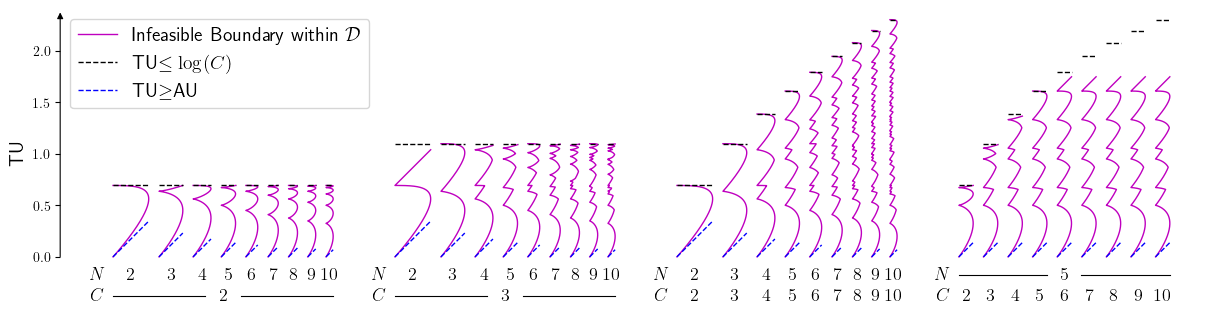

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

pairs = [
    [(2, i) for i in range(2, 11)],
    [(3, i) for i in range(2, 11)],
    [(i, i) for i in range(2, 11)],
    [(i, 5) for i in range(2, 11)],
]

lw = 1
color = "m"
eps_x = 0.1
eps_y = 0.5

plt.rcParams["text.usetex"] = True

fig, ax = plt.subplots(figsize=(15, 10))

delta_x = 0
first = True

# Store x-centres / extents for the table below
group_info = []

for j, pairs_j in enumerate(pairs):

    curve_info = []
    group_xmin = None
    group_xmax = None

    for i, (C, N) in enumerate(pairs_j):

        AU, EU, TU = entu.get_theoretical_min_boundary(
            num_classes=C,
            num_ensemble=N,
            interp=False,
            detailed=False,
        )

        max_AU = np.log(2) / N
        max_TU = np.log(C)

        x = AU + delta_x

        ax.plot(
            x, TU,
            lw=lw,
            color=color,
            label=r"Infeasible Boundary within $\mathcal{D}$" if first else None,
        )

        ax.plot(
            [delta_x, delta_x + max_AU],
            [max_TU, max_TU],
            "k--",
            lw=lw,
            label=r"TU$\leq\log(C)$" if first else None,
        )

        ax.plot(
            [delta_x, delta_x + max_AU],
            [0, max_AU],
            "b--",
            lw=lw,
            label=r"TU$\geq$AU" if first else None,
        )

        first = False

        # Centre of THIS curve according to its actual horizontal extent
        xmin = np.min(x)
        xmax = np.max(x)
        xcenter = 0.5 * (xmin + xmax)

        curve_info.append({
            "C": C,
            "N": N,
            "xmin": xmin,
            "xmax": xmax,
            "xcenter": xcenter,
        })

        if group_xmin is None:
            group_xmin = xmin
        group_xmax = xmax

        delta_x += max_AU + eps_x

    group_info.append({
        "curves": curve_info,
        "xmin": group_xmin,
        "xmax": group_xmax,
        "xcenter": 0.5 * (group_xmin + group_xmax),
    })

    delta_x += eps_y


# ---------------------------------------------------------------------
# Table-like N / C labels below curves
# ---------------------------------------------------------------------

y_N = -0.18
y_C = -0.38

table_fontsize = 13
line_lw = 0.8

# Row titles before each group
title_gap = 0.10

for info in group_info:
    x_row_title = info["xmin"] - title_gap

    ax.text(
        x_row_title, y_N,
        r"$N$",
        ha="right", va="center",
        fontsize=table_fontsize,
    )

    ax.text(
        x_row_title, y_C,
        r"$C$",
        ha="right", va="center",
        fontsize=table_fontsize,
    )


def draw_group_value(ax, xmin, xmax, y, value, fontsize=13, gap_frac=0.08):
    """
    Draw something visually like

        -------- 2 --------

    with the number centred over the full horizontal extent.
    """
    xmid = 0.5 * (xmin + xmax)
    width = xmax - xmin

    gap = gap_frac * width

    ax.plot(
        [xmin, xmid - gap],
        [y, y],
        color="k",
        lw=line_lw,
        clip_on=False,
    )

    ax.plot(
        [xmid + gap, xmax],
        [y, y],
        color="k",
        lw=line_lw,
        clip_on=False,
    )

    ax.text(
        xmid, y,
        rf"${value}$",
        ha="center",
        va="center",
        fontsize=fontsize,
    )


for info in group_info:

    curves = info["curves"]

    Ns = [d["N"] for d in curves]
    Cs = [d["C"] for d in curves]

    # -------------------------------------------------------------
    # N row
    # -------------------------------------------------------------
    if len(set(Ns)) == 1:
        # One N shared by the entire group
        draw_group_value(
            ax,
            info["xmin"],
            info["xmax"],
            y_N,
            Ns[0],
            fontsize=table_fontsize,
        )
    else:
        # Separate N below each individual curve
        for d in curves:
            ax.text(
                d["xcenter"], y_N,
                rf"${d['N']}$",
                ha="center",
                va="center",
                fontsize=table_fontsize,
            )

    # -------------------------------------------------------------
    # C row
    # -------------------------------------------------------------
    if len(set(Cs)) == 1:
        # One C shared by the entire group
        draw_group_value(
            ax,
            info["xmin"],
            info["xmax"],
            y_C,
            Cs[0],
            fontsize=table_fontsize,
        )
    else:
        # Separate C below each individual curve
        for d in curves:
            ax.text(
                d["xcenter"], y_C,
                rf"${d['C']}$",
                ha="center",
                va="center",
                fontsize=table_fontsize,
            )


# ---------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------

ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left", fontsize=14)

# Hide standard spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.get_xaxis().set_visible(False)

ax.set_ylabel("TU", fontsize=14)

# ---------------------------------------------------------------------
# Custom y-axis with arrowhead
# ---------------------------------------------------------------------

# Need negative plotting space for N/C labels
ax.set_ylim(y_C - 0.02, 2.4)
yticks = ax.get_yticks()
ax.set_yticks(yticks[(yticks >= 0) & (yticks <= 2.4)])

# Custom y-axis with arrow
xmin_plot, xmax_plot = ax.get_xlim()
ymin_plot, ymax_plot = ax.get_ylim()

x_axis = xmin_plot
axis_bottom = -0.025  # tiny extension below the 0.0 tick

ax.annotate(
    "",
    xy=(x_axis, ymax_plot),
    xytext=(x_axis, axis_bottom),
    arrowprops=dict(
        arrowstyle="-|>",
        color="k",
        lw=0.8,
        mutation_scale=9,
    ),
    annotation_clip=False,
)

# Keep ordinary y ticks
ax.yaxis.set_ticks_position("left")


plt.savefig(
     "../writing/images/boundary_shapes.pdf",
     dpi=300,
     bbox_inches="tight",
)

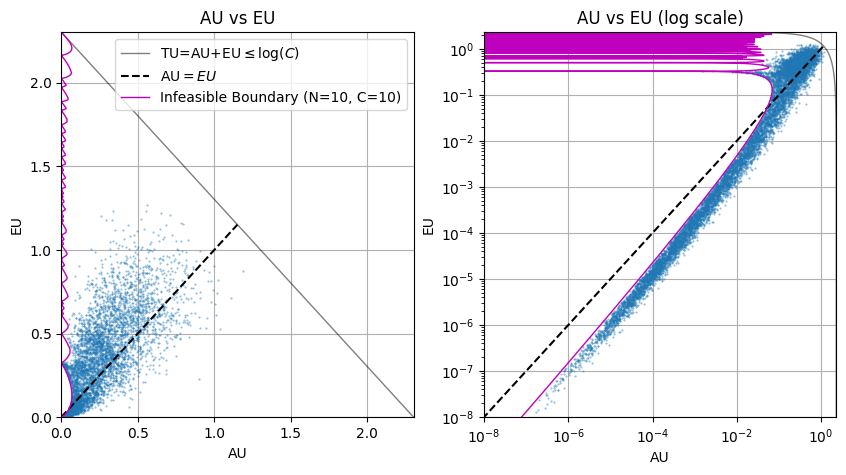

In [66]:
import glob
p = "/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-08-27/"
file_paths = list(glob.glob(p + "*/val_logits.csv"))
file_paths = [s for s in file_paths if "C7-Enet" not in s]

ens_logits = entu.load_ens_logits(file_paths)
ens_logits["probs"] = ens_logits["probs"]#.float()
#ens_logits["paths"]
fig, axs = entu.ensemble_plot_log(ens_logits,plot_boundary=1,interp=0, limits=[(1e-8,np.log(10)),(1e-8,np.log(10))],
                                  gt_colormap=0, lw=1, plot_xy=1, alpha=0.5)
axs[0].set_title("AU vs EU")
axs[1].set_title("AU vs EU (log scale)")
#turn off second legend
axs[1].legend_.remove()
#change lower xlim and ylim from ax[0] to 0
axs[0].set_xlim(left=0)
axs[0].set_ylim(bottom=0)
#change figsize
fig.set_size_inches(10, 5)

fig.savefig("../writing/images/cifar_10classes_scatter.png", dpi=300, bbox_inches='tight')

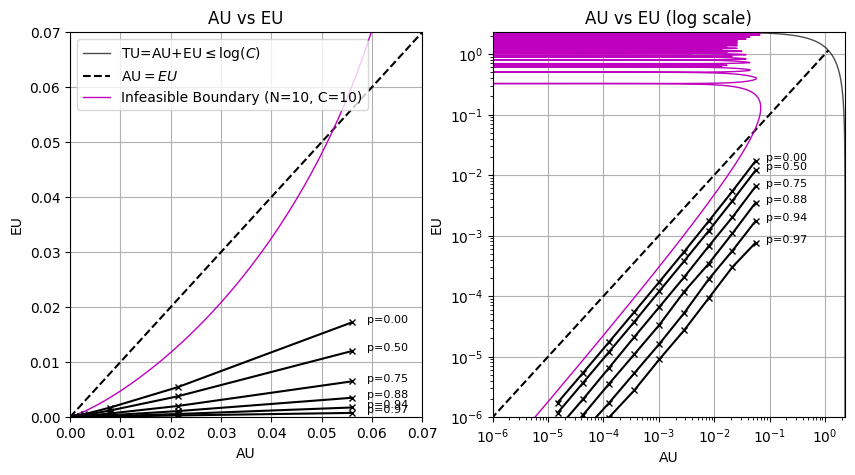

In [166]:
fig, axs = entu.ensemble_plot_log(ens_logits=None,plot_boundary=1,interp=0, 
                                  limits=[(1e-6,np.log(10)),(1e-6,np.log(10))],
                                  gt_colormap=0, lw=1, plot_xy=1, C=10, N=10)
axs[0].set_title("AU vs EU")
axs[1].set_title("AU vs EU (log scale)")
#turn off second legend
axs[1].legend_.remove()

#change figsize
fig.set_size_inches(10, 5)
eps_vec = np.logspace(-6, -2, 9)
p_vec = [0, 1-2**-1, 1-2**-2, 1-2**-3, 1-2**-4, 1-2**-5]

N = 10
n_samples = 1000
C = 10
P = 10

AUss, EUss, TUss = [], [], []

for eps in eps_vec:
    #p_vec = np.linspace(1/(C-1),1.0,P)
    

    # simulate points
    #eps = 0.01  # now using eps from eps_vec
    ens_logits = np.zeros((N, n_samples, C))
    ens_logits[:, :, 0] = 1 - eps
    #ENS_LOGITS = []
    AUs, EUs, TUs = [], [], []
    #p is the probability that the second class is given the probabillity mass
    for p in p_vec:
        v = ens_logits.copy()
        distribution = np.array([0] + [ (1 - p) / (C - 1) ] * (C - 1))
        distribution[1] += p
        #n_sample indices from the distribution
        indices = np.random.choice(C, size=(N, n_samples), p=distribution)
        for i in range(N):
            for j in range(n_samples):
                v[i, j, indices[i, j]] = eps
        #ENS_LOGITS.append(v)
        AU, EU, TU = entu.uncertainties(torch.tensor(v))
        if EU.mean() < 1e-10:
            print(EU)
            raise ValueError("EU.mean() below the threshold")
        AUs.append(AU.mean())
        EUs.append(EU.mean())
        TUs.append(TU.mean())
    AUss.append(AUs)
    EUss.append(EUs)
    TUss.append(TUs)
EUss = np.array(EUss).T
AUss = np.array(AUss).T
TUss = np.array(TUss).T
#change lower xlim and ylim from ax[0] to 0
axs[0].set_xlim(left=0,right=0.07)
axs[0].set_ylim(bottom=0, top=0.07)
for ax in axs:
    for i, p in enumerate(p_vec):
        ax.plot(AUss[i], EUss[i], "x-", color="k", markersize=5)
        # plot text with p= at the last point
        ax.text(AUss[i][-1]+(0.003 if ax==axs[0] else 0.03), EUss[i][-1], f"p={p:.2f}", fontsize=8)
axs[0].legend(loc="upper left")